In [24]:
import pandas as pd
import seaborn as sns               # 底层依赖 Matplotlib 
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 演示 Pandas绘图.

In [2]:
# 1. 加载数据源, 获取到 df对象.
df = pd.read_csv('../RFM案例/data/winemag-data_first150k.csv', index_col=0)
df

,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
...,...,...,...,...,...,...,...,...,...,...
150925,Italy,Many people feel Fiano represents southern Ita...,NaN,91,20.0,Southern Italy,Fiano di Avellino,NaN,White Blend,Feudi di San Gregorio
150926,France,"Offers an intriguing nose with ginger, lime an...",Cuvée Prestige,91,27.0,Champagne,Champagne,NaN,Champagne Blend,H.Germain
150927,Italy,This classic example comes from a cru vineyard...,Terre di Dora,91,20.0,Southern Italy,Fiano di Avellino,NaN,White Blend,Terredora
150928,France,"A perfect salmon shade, with scents of peaches...",Grand Brut Rosé,90,52.0,Champagne,Champagne,NaN,Champagne Blend,Gosset


<Axes: xlabel='province'>

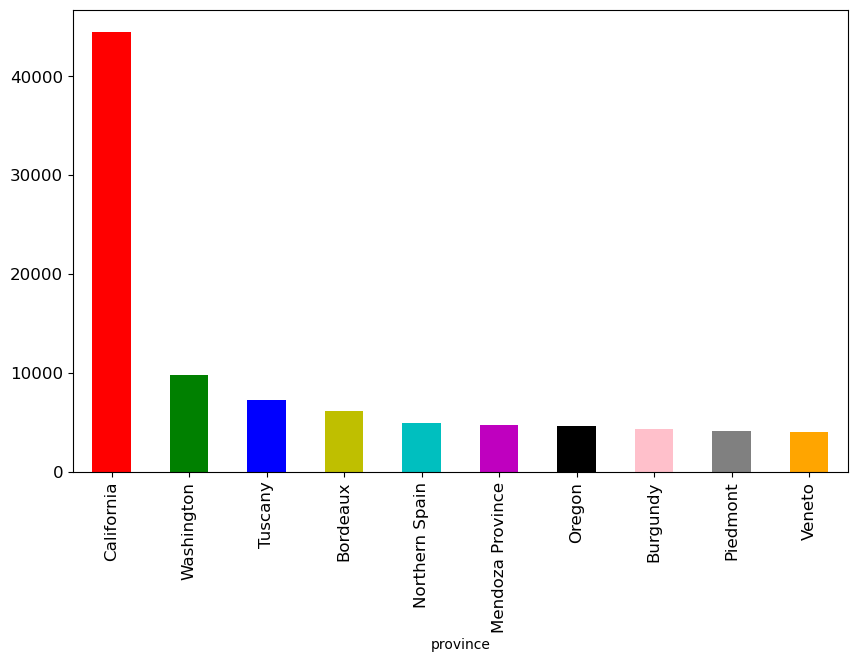

In [13]:
# 需求1: 绘制图形, 展示 产葡萄酒最多的10个产地的信息. 
# 方式1: 使用 groupby()方法.
df.groupby('province')['province'].count().sort_values(ascending=False).head(10)

# 方式2: value_counts()  统计每个值的次数, 等价于: groupby()方法 + 聚合count() + 排序(默认: 降序)
df['province'].value_counts().head(10)

# 对上述结果进行可视化, 采用 Pandas自带的 绘图方式.
# df['province'].value_counts().head(10).plot()                 # 折线图.

# 柱状图
text_kwargs = dict(fontsize=12, figsize=(10, 6), color=['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray', 'orange'])
# print(text_kwargs)      # {'fontsize': 15, 'figsize': (10, 6), 'color': ['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray', 'orange']}

df['province'].value_counts().head(10).plot.bar(**text_kwargs)


<Axes: xlabel='province'>

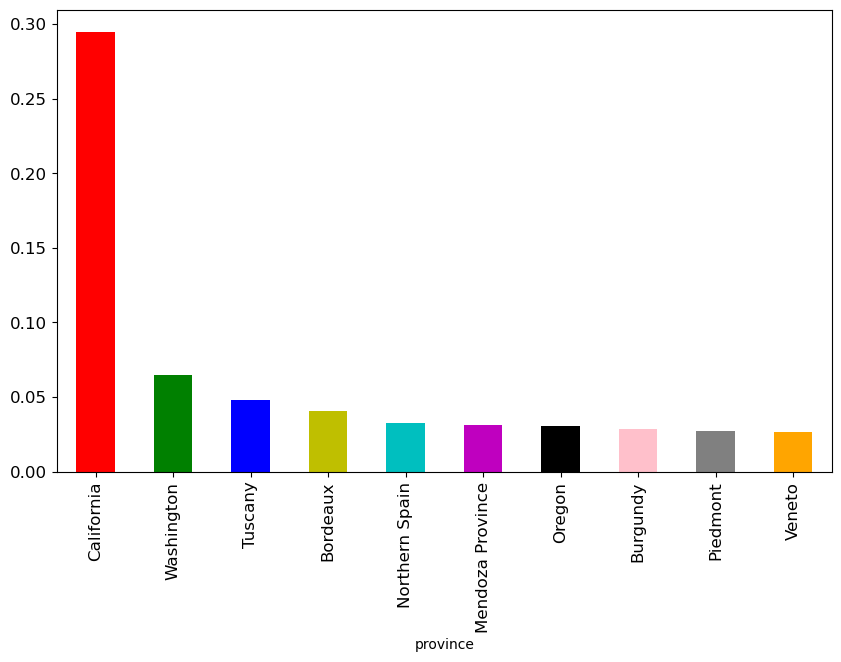

In [14]:
# 需求2: 展示 产葡萄酒最多的10个产地的 占比.
(df['province'].value_counts().head(10) / len(df)).plot.bar(**text_kwargs)

<Axes: xlabel='points'>

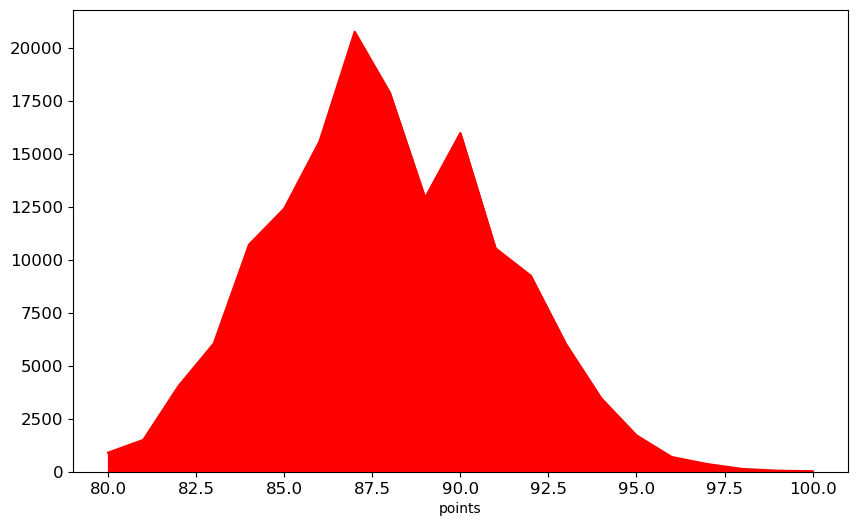

In [17]:
# 需求3: 展示 每个评分的葡萄酒种类(个数) 
# df['points'].value_counts().sort_index().plot.bar(**text_kwargs)          # 柱状图

# 如果是固定值的数据, 不是分类性的, 可以直接使用: 折线图显示. 
# df['points'].value_counts().sort_index().plot.line(**text_kwargs)          # 折线图
df['points'].value_counts().sort_index().plot.area(**text_kwargs)            # 面积图 = 把折线图的空白填充成颜色即可.

# 2. 演示Seaborn绘图

In [19]:
# 1. 读取数据, 获取df对象. 
# df = pd.read_csv('./data/tips.csv')
df = sns.load_dataset('tips')       # 加载Seaborn包自带的 内置数据集, 前提: 电脑要联网.
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Text(0.5, 1.0, '男女总账单分布情况')

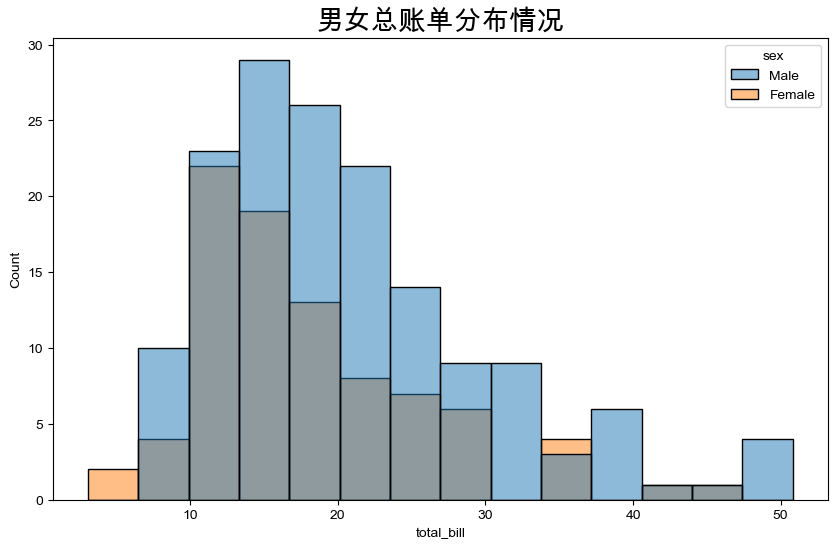

In [27]:
# seaborn的绘图, 基本上都是:  图形名 + plot()即可.
# 例如: Pandas中 直方图叫 hist(), seaborn中 直方图叫 histplot()
# 2. 绘制图形, 展示 每天 男女 总账单的情况.
# 计数柱状图, data: 要操作的df对象, x: 绘制的列名, hue: 分组列名.
# sns.countplot(data=df, x='day', hue='sex')

# 3. 绘制图形, 展示 男女 总账单的情况.
fig, ax = plt.subplots(figsize=(10, 6))

# # 直方图, data: 要操作的df对象, x: 绘制的列名, hue: 分组列名.
sns.histplot(data=df, x='total_bill', hue='sex')

ax.set_title('男女总账单分布情况', fontsize=20)
# plt.show()

Text(0.5, 1.0, '总账单金额 和 小费金额 的关系图')

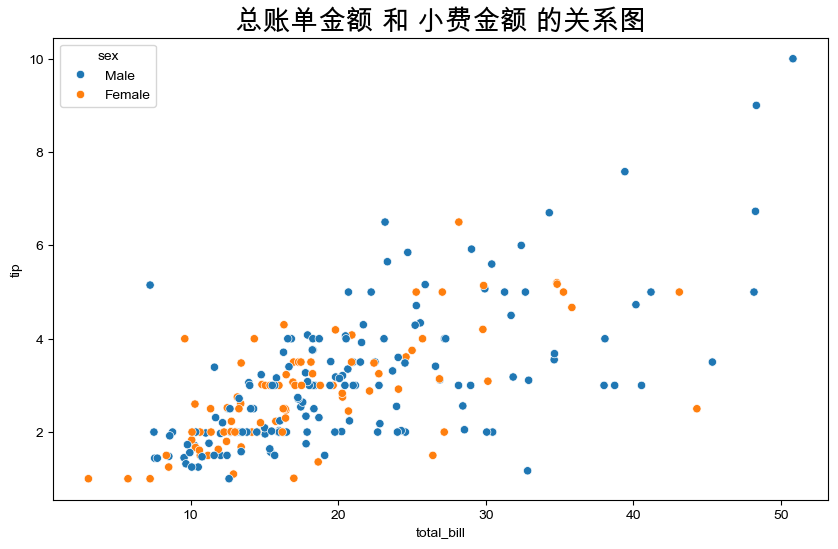

In [29]:
# 需求: 描述 总账单金额 和 小费的分布情况(关系图) -> 散点图
# x轴 -> 总账单金额, y轴 -> 小费金额.
fig, ax = plt.subplots(figsize=(10, 6))
# 参1: 要操作的df对象, x: 总账单金额, y: 小费金额.
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
ax.set_title('总账单金额 和 小费金额 的关系图', fontsize=20)
plt.show()

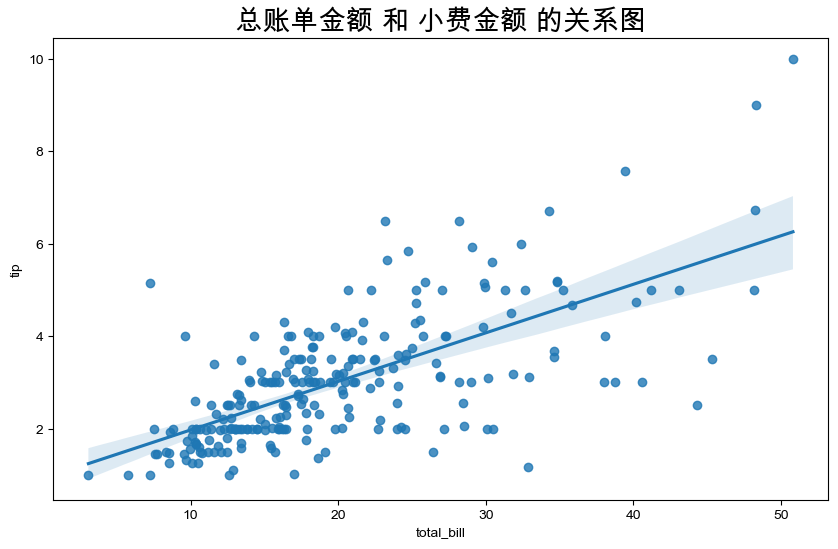

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
# 参1: 要操作的df对象, x: 总账单金额, y: 小费金额.
sns.regplot(data=df, x='total_bill', y='tip')       # 会绘制1条拟合回归线, 默认是线性回归.
ax.set_title('总账单金额 和 小费金额 的关系图', fontsize=20)
plt.show()

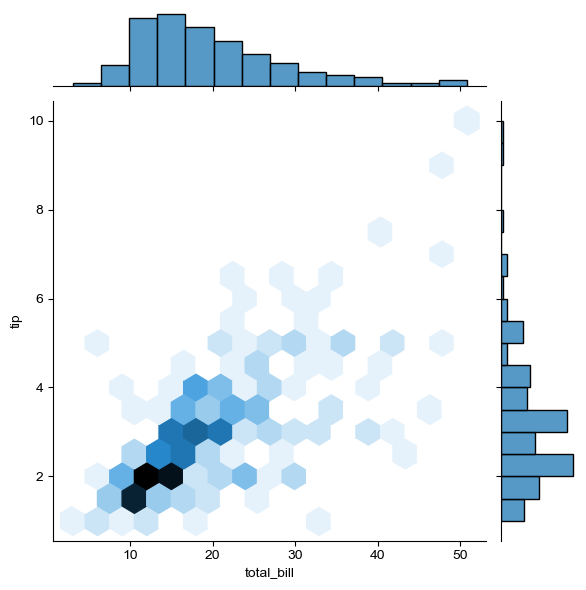

In [33]:
# 参1: 要操作的df对象, x: 总账单金额, y: 小费金额.
# sns.jointplot(data=df, x='total_bill', y='tip', kind='reg')       # 会绘制1条拟合回归线, 默认是线性回归.
sns.jointplot(data=df, x='total_bill', y='tip', kind='hex')         # kind='hex' -> 蜂巢图
ax.set_title('总账单金额 和 小费金额 的关系图', fontsize=20)
plt.show()

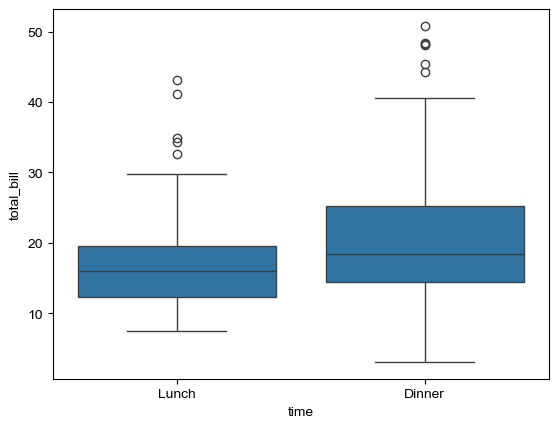

In [34]:
# 参1: 要操作的df对象, x: 时间(午餐, 晚餐), y: 账单总金额.
# 箱线图. 盒须图 盒子是中位数, 竖线是中位数, 线段是上下四分位值IQR. 线段范围外的是离群点.
sns.boxplot(data=df, x='time', y='total_bill')
plt.show()

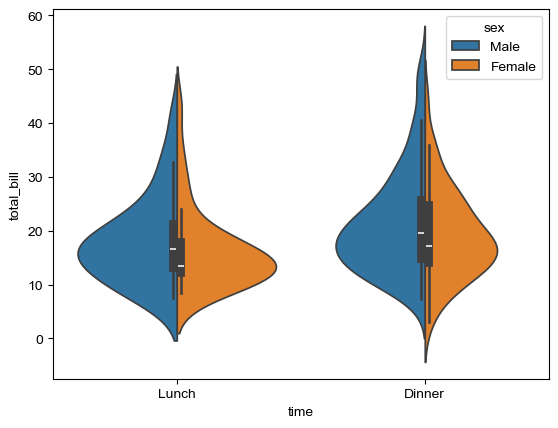

In [35]:
# 参1: 要操作的df对象, x: 时间(午餐, 晚餐), y: 账单总金额.
# 小提琴图.
sns.violinplot(data=df, x='time', y='total_bill', hue='sex', split=True) # split=True 不加显示4个图 男女都单独显示
plt.show()